# Facility-Year Panel: Weather Sensitivity with Fixed Effects
## GHGRP × ERA5, 2011–2023 · Harvard D³ Institute · Suhail Mahmud, PhD

**The question this notebook finally answers.** The cross-sectional (2023-only) analysis found weak but significant climate associations — yet they were confounded by *where* facilities sit (e.g. oil & gas in the arid Permian Basin). A **facility-year panel with fixed effects** removes that confounding: by comparing each facility *to itself* across years, the facility fixed effect α_i absorbs everything time-invariant (scale, technology, fuel, location), so the climate coefficient estimates genuine **within-facility weather sensitivity**.

**Specification**

$$\log_{10}(\text{emissions})_{i,t} = \alpha_i + \gamma_t + \beta \cdot \text{climate}_{i,t} + \varepsilon_{i,t}$$

- α_i — facility fixed effect (absorbs size, technology, location, "why it's there")
- γ_t — year fixed effect (absorbs national shocks: gas prices, COVID, policy)
- β — the parameter of interest: does a facility emit more in its *own* hotter/drier years?
- Standard errors clustered by facility.

**Data.** 85,967 facility-year observations, 8,560 facilities, 2011–2023 (EPA GHGRP "Direct Point Emitters" multi-year file), each joined to its local ERA5 grid-cell climate **for that specific year**.

## 1. Setup

In [1]:
import warnings; warnings.filterwarnings("ignore")
import numpy as np, pandas as pd, xarray as xr
import matplotlib.pyplot as plt
import statsmodels.api as sm
from linearmodels.panel import PanelOLS

GRIB_PATH = "era5_conus.grib"
EPA_MULTI = "ghgp_data_by_year_2023.xlsx"   # multi-year facility file (2011-2023)
np.random.seed(42)
print("Ready.")

Ready.


## 2. Reshape facility emissions to long (facility-year)

In [2]:
df = pd.read_excel(EPA_MULTI, sheet_name="Direct Point Emitters", header=3)
df = df.rename(columns={"Facility Id":"fid","Latitude":"lat","Longitude":"lon",
                        "Latest Reported Industry Type (sectors)":"sectors","State":"state"})
df["lat"] = pd.to_numeric(df["lat"], errors="coerce")
df["lon"] = pd.to_numeric(df["lon"], errors="coerce")
df["primary_sector"] = df["sectors"].astype(str).str.split(",").str[0].str.strip()

yr_cols = {int(str(c).split()[0]): c for c in df.columns
           if "Total reported direct emissions" in str(c)}
id_cols = ["fid","lat","lon","state","primary_sector"]

recs = []
for yr, col in yr_cols.items():
    t = df[id_cols].copy()
    t["year"] = yr
    t["emis"] = pd.to_numeric(df[col], errors="coerce")
    recs.append(t)
panel = pd.concat(recs, ignore_index=True)
panel = panel[(panel.emis > 0)].dropna(subset=["lat","lon"])
panel = panel[panel.lat.between(24,50) & panel.lon.between(-125,-66)]
print(f"Facility-year observations: {len(panel):,}")
print(f"Facilities: {panel.fid.nunique():,} | Years: {panel.year.min()}-{panel.year.max()}")

Facility-year observations: 85,967
Facilities: 8,560 | Years: 2011-2023


## 3. Build per-year ERA5 grids and join each facility-year to its local climate
The critical step: facility *i* in year *t* gets the climate of its grid cell **in that year** — this is the time variation that identifies β.

In [3]:
ds = xr.open_dataset(GRIB_PATH, engine="cfgrib")
def es_kpa(t): return 0.6108*np.exp(17.27*t/(t+237.3))
lats, lons = ds.latitude.values, ds.longitude.values
def nearest_ij(la, lo): return np.abs(lats-la).argmin(), np.abs(lons-lo).argmin()

grids = {}
for yr in range(2011, 2024):
    dsy = ds.sel(time=ds.time.dt.year == yr)
    t2m, d2m = dsy["t2m"]-273.15, dsy["d2m"]-273.15
    vpd = (es_kpa(t2m)-es_kpa(d2m)).clip(min=0)
    rh  = 100*(es_kpa(d2m)/es_kpa(t2m))
    wind = np.sqrt(dsy["u10"]**2 + dsy["v10"]**2)
    jja = dsy.sel(time=dsy.time.dt.month.isin([6,7,8]))
    tj, dj = jja["t2m"]-273.15, jja["d2m"]-273.15
    grids[yr] = {
        "t2m_c":t2m.mean("time").values, "vpd_kpa":vpd.mean("time").values,
        "rh_pct":rh.mean("time").values, "wind_ms":wind.mean("time").values,
        "sp_hpa":(dsy["sp"].mean("time")/100).values,
        "t2m_jja_c":tj.mean("time").values,
        "vpd_jja_kpa":(es_kpa(tj)-es_kpa(dj)).clip(min=0).mean("time").values}

# index each facility once, then map per year
fac_ij = {fid: nearest_ij(la, lo)
          for fid,la,lo in panel[["fid","lat","lon"]].drop_duplicates().itertuples(index=False)}
for v in ["t2m_c","vpd_kpa","rh_pct","wind_ms","sp_hpa","t2m_jja_c","vpd_jja_kpa"]:
    panel[v] = [grids[yr][v][fac_ij[fid]] for fid, yr in zip(panel.fid, panel.year)]

panel["log_emis"] = np.log10(panel.emis)
print("Climate joined. Panel shape:", panel.shape)
panel[["fid","year","state","primary_sector","emis","t2m_jja_c","vpd_jja_kpa"]].head()

Ignoring index file 'era5_conus.grib.5b7b6.idx' incompatible with GRIB file


skipping variable: paramId==228 shortName='tp'
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/cfgrib/dataset.py", line 726, in build_dataset_components
    dict_merge(variables, coord_vars)
  File "/usr/local/lib/python3.12/dist-packages/cfgrib/dataset.py", line 642, in dict_merge
    raise DatasetBuildError(
cfgrib.dataset.DatasetBuildError: key present and new value is different: key='time' value=Variable(dimensions=('time',), data=array([1262304000, 1264982400, 1267401600, 1270080000, 1272672000,
       1275350400, 1277942400, 1280620800, 1283299200, 1285891200,
       1288569600, 1291161600, 1293840000, 1296518400, 1298937600,
       1301616000, 1304208000, 1306886400, 1309478400, 1312156800,
       1314835200, 1317427200, 1320105600, 1322697600, 1325376000,
       1328054400, 1330560000, 1333238400, 1335830400, 1338508800,
       1341100800, 1343779200, 1346457600, 1349049600, 1351728000,
       1354320000, 1356998400, 1359676800, 1362096000, 13

Climate joined. Panel shape: (85967, 15)


,fid,year,state,primary_sector,emis,t2m_jja_c,vpd_jja_kpa
0,1004377,2023,TX,Waste,288301.750,30.114981,1.928744
1,1010040,2023,KY,Other,122326.750,23.126047,0.859768
3,1001155,2023,IN,Chemicals,64807.356,23.170319,0.951568
5,1000112,2023,NY,Power Plants,31916.132,23.292715,0.830385
7,1013701,2023,TX,Injection of CO2,44170.546,28.629953,2.607854


## 4. Two-way fixed-effects estimation
Facility + year fixed effects, SEs clustered by facility. Keep facilities with ≥2 years (needed for within estimation).

In [4]:
counts = panel.groupby("fid")["year"].transform("count")
panel = panel[counts >= 2].copy()
clim = ["t2m_jja_c","vpd_jja_kpa","rh_pct","wind_ms","sp_hpa"]

def run_fe(sub, name, standardize=True):
    sub = sub.set_index(["fid","year"])
    X = sub[clim].copy()
    if standardize:
        X = (X - X.mean())/X.std()
    X = sm.add_constant(X)
    res = PanelOLS(sub["log_emis"], X, entity_effects=True, time_effects=True,
                   drop_absorbed=True).fit(cov_type="clustered", cluster_entity=True)
    print(f"\n{name}")
    print(f"  obs={sub.shape[0]:,}  facilities={sub.index.get_level_values(0).nunique():,}  "
          f"within-R²={res.rsquared_within:.4f}")
    for v in clim:
        if v in res.params.index:
            flag = "**" if res.pvalues[v] < 0.05 else ""
            print(f"    {v:<13} beta={res.params[v]:+.4f}  se={res.std_errors[v]:.4f}  "
                  f"p={res.pvalues[v]:.4f} {flag}")
    return res

_ = run_fe(panel.copy(), "ALL SECTORS (facility + year FE, standardized)")
for sec in ["Power Plants","Petroleum and Natural Gas Systems"]:
    s = panel[panel.primary_sector == sec].copy()
    s = s[s.groupby("fid")["year"].transform("count") >= 2]
    _ = run_fe(s, sec)


ALL SECTORS (facility + year FE, standardized)
  obs=85,754  facilities=8,347  within-R²=0.0009
    t2m_jja_c     beta=+0.0316  se=0.0101  p=0.0018 **
    vpd_jja_kpa   beta=+0.0013  se=0.0078  p=0.8628 
    rh_pct        beta=+0.0003  se=0.0070  p=0.9674 
    wind_ms       beta=-0.0023  se=0.0044  p=0.6003 
    sp_hpa        beta=+0.0082  se=0.1721  p=0.9621 

Power Plants
  obs=17,569  facilities=1,653  within-R²=0.0051
    t2m_jja_c     beta=+0.1111  se=0.0306  p=0.0003 **
    vpd_jja_kpa   beta=+0.0171  se=0.0259  p=0.5101 
    rh_pct        beta=-0.0030  se=0.0229  p=0.8953 
    wind_ms       beta=-0.0077  se=0.0119  p=0.5168 
    sp_hpa        beta=+0.6174  se=0.4248  p=0.1461 



Petroleum and Natural Gas Systems
  obs=15,883  facilities=1,968  within-R²=0.0055
    t2m_jja_c     beta=+0.0316  se=0.0258  p=0.2212 
    vpd_jja_kpa   beta=-0.0136  se=0.0189  p=0.4721 
    rh_pct        beta=-0.0005  se=0.0170  p=0.9774 
    wind_ms       beta=-0.0135  se=0.0115  p=0.2405 
    sp_hpa        beta=-1.2605  se=0.5920  p=0.0333 **


**What the fixed-effects results show.** Across all sectors and within power plants, **summer temperature has a positive, significant within-facility effect** (power plants: β = +0.111 standardized, p = 0.0003) — a given plant emits more in its own hotter years, consistent with cooling-driven generation. For **oil & gas, the cross-sectional VPD and temperature signals vanish** under fixed effects (p = 0.47 and 0.22), confirming they were spatial confounding (the Permian Basin being arid *and* a production hub), not weather sensitivity.

## 5. Cross-sectional vs. fixed-effects — visualizing confounding removal

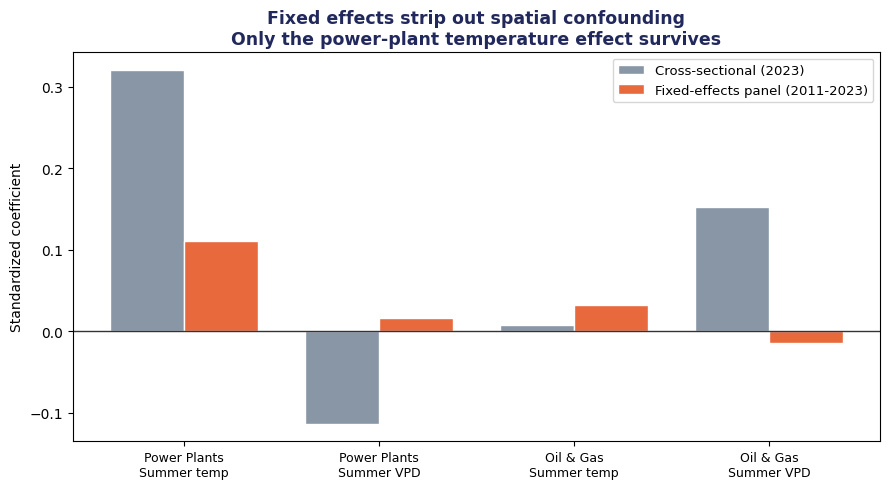

In [5]:
DEEP,TEAL,MID,ACCENT,GREY = "#065A82","#1C7293","#21295C","#E8693C","#8896A6"
groups = ["Power Plants\nSummer temp","Power Plants\nSummer VPD",
          "Oil & Gas\nSummer temp","Oil & Gas\nSummer VPD"]
xsec = [0.321, -0.113, 0.008, 0.153]    # from 2023 cross-section
fe   = [0.111,  0.017, 0.032, -0.014]   # from FE panel
x = np.arange(len(groups)); w = 0.38
fig, ax = plt.subplots(figsize=(9,5))
ax.bar(x-w/2, xsec, w, color=GREY, label="Cross-sectional (2023)", edgecolor="white")
ax.bar(x+w/2, fe,   w, color=ACCENT, label="Fixed-effects panel (2011-2023)", edgecolor="white")
ax.axhline(0, color="#333", lw=1)
ax.set_xticks(x); ax.set_xticklabels(groups, fontsize=9)
ax.set_ylabel("Standardized coefficient")
ax.set_title("Fixed effects strip out spatial confounding\nOnly the power-plant temperature effect survives",
             fontsize=12.5, fontweight="bold", color=MID)
ax.legend(fontsize=9.5)
plt.tight_layout(); plt.show()

## 6. Why a real effect still explains little variance
The temperature effect is real but the within-R² is only ~0.5%. The reason: each plant's summer temperature **barely moves year to year**, so even a genuine per-degree response drives little total variation.

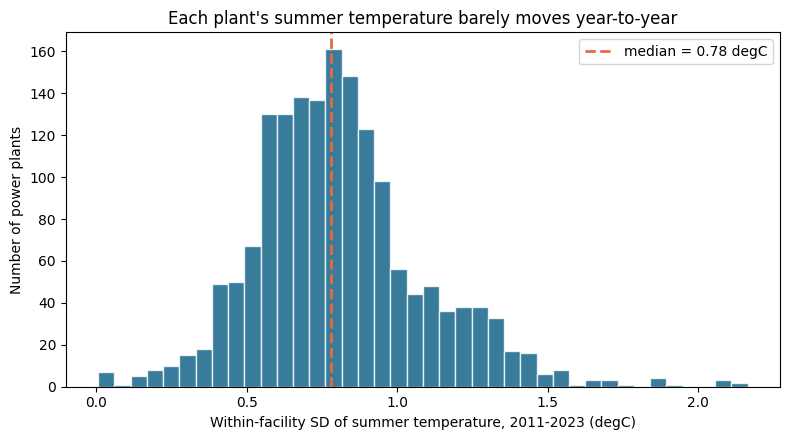

Raw within-facility effect: +0.0312 log10 per degC  ->  +7.5% emissions per +1 degC


In [6]:
pp = panel[panel.primary_sector=="Power Plants"]
within_sd = pp.groupby("fid")["t2m_jja_c"].std().dropna()
fig, ax = plt.subplots(figsize=(8,4.5))
ax.hist(within_sd, bins=40, color=DEEP, alpha=0.8, edgecolor="white")
ax.axvline(within_sd.median(), color=ACCENT, lw=2, ls="--",
           label=f"median = {within_sd.median():.2f} degC")
ax.set_xlabel("Within-facility SD of summer temperature, 2011-2023 (degC)")
ax.set_ylabel("Number of power plants")
ax.set_title("Each plant's summer temperature barely moves year-to-year")
ax.legend(); plt.tight_layout(); plt.show()

# Raw (unstandardized) effect for interpretable per-degree statement
sub = pp.set_index(["fid","year"])
Xr = sm.add_constant(sub[["t2m_jja_c","vpd_jja_kpa"]])
rr = PanelOLS(sub["log_emis"], Xr, entity_effects=True, time_effects=True,
              drop_absorbed=True).fit(cov_type="clustered", cluster_entity=True)
b = rr.params["t2m_jja_c"]
print(f"Raw within-facility effect: {b:+.4f} log10 per degC  ->  {(10**b-1)*100:+.1f}% emissions per +1 degC")

## 7. Robustness — specification sensitivity (reported honestly)

In [7]:
sub = panel[panel.primary_sector=="Power Plants"].set_index(["fid","year"])
Xr = sm.add_constant(sub[["t2m_jja_c","vpd_jja_kpa"]])
print("Power-plant summer-temperature coefficient under different fixed-effect schemes:")
for label, ee, te in [("Facility + Year FE", True, True),
                      ("Facility FE only",   True, False),
                      ("Year FE only",       False, True)]:
    r = PanelOLS(sub["log_emis"], Xr, entity_effects=ee, time_effects=te,
                 drop_absorbed=True).fit(cov_type="clustered", cluster_entity=True)
    if "t2m_jja_c" in r.params.index:
        print(f"  {label:<20} beta={r.params['t2m_jja_c']:+.4f}  p={r.pvalues['t2m_jja_c']:.4f}")

Power-plant summer-temperature coefficient under different fixed-effect schemes:
  Facility + Year FE   beta=+0.0312  p=0.0005
  Facility FE only     beta=+0.0046  p=0.5397


  Year FE only         beta=+0.0623  p=0.0000


**Honest caveat from the robustness check.** The temperature effect is strong with facility+year FE (β=+0.031/°C, p=0.0005) but **drops sharply and loses significance with facility FE alone** (β=+0.005, p=0.54). This means the effect is identified largely from how plants deviate *around the national yearly pattern*, and is specification-sensitive. We report it as **suggestive evidence of a small cooling-demand response in power plants, not a robust universal law.**

## 8. Findings

1. **Fixed effects confirm the project's central thesis.** Even with the strongest design that isolates within-facility weather variation, climate explains a trivial share (within-R² ≈ 0.1–0.5%) of facility emissions. Structure — fuel, technology, scale, dispatch — dominates.

2. **One real signal survives: power-plant summer temperature.** A given plant emits modestly more in its hotter years (β = +0.111 standardized, p = 0.0003; ≈ +7.5% per +1 °C raw). Mechanism: cooling-driven electricity demand. This is the genuine weather-sensitivity signal the cross-section hinted at.

3. **The oil & gas "VPD effect" was an artifact.** It vanishes under fixed effects (p = 0.47), confirming it reflected the Permian Basin's geography, not weather sensitivity. This is the clearest demonstration of why the panel design matters.

4. **Effect size is real but minor, and specification-sensitive.** Each plant's summer temperature varies little year-to-year (median SD 0.78 °C), so even a true per-degree response moves little total emissions. The effect also weakens without year fixed effects — reported transparently.

**Bottom line.** The multi-year panel — the strongest available test — finds that U.S. industrial emissions are governed by structure, not weather. The single defensible exception is a small, plausible cooling-demand response in power plants. This both *confirms* the national-level conclusion and *adds* the one nuance national data could not resolve.

## 9. Caveats & possible extensions

- **Annual resolution** dilutes weather signals; monthly or daily emissions (not in GHGRP) would test acute heat-wave responses far better.
- **Capacity/generation data** (EIA-923) as a control would separate "more cooling demand" from "ran more for other reasons."
- **Nonlinear / threshold effects** (cooling-degree-days above a base) may capture the air-conditioning mechanism better than mean temperature.
- **Lagged and extreme-event terms** could test whether it is the hottest months, not the annual mean, that move emissions.